In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pandas.api.types import is_numeric_dtype

plt.style.use("ggplot")

# agar semua kolom tampil
pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("dataset_stunting_sintetis.csv")

df.head()

,ID_Anak,Tanggal_Pemeriksaan,Tahun,Bulan,Usia_Bulan,Jenis_Kelamin,Provinsi,Kabupaten_Kota,Kecamatan,Desa_Kelurahan,Latitude,Longitude,Tempat_Pemeriksaan,Berat_Badan_kg,Tinggi_Badan_cm,Lingkar_Kepala_cm,LiLA_cm,BB_Lahir_gram,PB_Lahir_cm,Usia_Kehamilan_Minggu,Prematur,ASI_Eksklusif,Usia_MPASI_Bulan,Protein_Hewani_per_Minggu,Skor_Keragaman_Pangan,Riwayat_Diare,Riwayat_ISPA,Riwayat_TBC,Status_Imunisasi,Air_Bersih,Jamban_Sehat,Kebiasaan_Cuci_Tangan,Tinggi_Ibu_cm,Tinggi_Ayah_cm,Pendidikan_Ibu,Pendidikan_Ayah,Pekerjaan_Ibu,Pekerjaan_Ayah,Pendapatan_Keluarga,Status_Stunting
0,ANK00001,6/28/2021,2021,6,49,P,Nusa Tenggara Timur,Timor Tengah Selatan,Kec. B,Desa Melati,-0.505668,110.799259,Puskesmas Pembantu,13.9,102.5,43.2,15.9,2910,50,41,0,1,5,6,4,1,0,0,Lengkap,0,1,Cukup,153,166,SD,SMA,Buruh,Karyawan,3990000,1
1,ANK00002,3/27/2023,2023,3,57,P,Jawa Barat,Bandung,Kec. A,Desa Kenanga,-3.584033,128.288514,Posyandu Melati,17.4,113.3,46.5,16.6,2744,46,36,1,1,4,5,3,1,0,0,Lengkap,0,1,Baik,150,171,SMA,SMA,IRT,Wiraswasta,1782000,1
2,ANK00003,1/15/2025,2025,1,14,P,DKI Jakarta,Jakarta Barat,Kec. B,Desa Anggrek,-10.190701,124.259860,Posyandu Mawar,8.0,56.8,37.3,12.0,3258,47,38,0,1,5,10,4,1,0,0,Tidak Lengkap,1,1,Cukup,144,165,SMA,SMA,PNS,Petani,4717000,1
3,ANK00004,10/1/2024,2024,10,15,L,Papua,Keerom,Kec. A,Desa Mawar,-3.719320,135.084155,Posyandu Mawar,5.0,66.0,36.5,12.8,3286,49,36,1,1,5,11,3,0,0,0,Lengkap,1,1,Baik,148,162,Tidak Sekolah,SMA,Wiraswasta,Karyawan,4600000,0
4,ANK00005,1/27/2025,2025,1,23,L,Papua Tengah,Paniai,Kec. A,Desa Anggrek,-1.221078,133.098382,Puskesmas Pembantu,8.5,71.9,37.8,13.6,3321,48,37,0,1,6,5,5,0,1,0,Lengkap,0,0,Baik,151,164,SMA,Sarjana,Wiraswasta,PNS,2638000,0


**Melihat Ukuran Dataset**

In [3]:
print("Jumlah Baris :", df.shape[0])
print("Jumlah Kolom :", df.shape[1])

Jumlah Baris : 10000
Jumlah Kolom : 40


**Informasi Dataset**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 40 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ID_Anak                    10000 non-null  object 
 1   Tanggal_Pemeriksaan        10000 non-null  object 
 2   Tahun                      10000 non-null  int64  
 3   Bulan                      10000 non-null  int64  
 4   Usia_Bulan                 10000 non-null  int64  
 5   Jenis_Kelamin              10000 non-null  object 
 6   Provinsi                   10000 non-null  object 
 7   Kabupaten_Kota             10000 non-null  object 
 8   Kecamatan                  10000 non-null  object 
 9   Desa_Kelurahan             10000 non-null  object 
 10  Latitude                   10000 non-null  float64
 11  Longitude                  10000 non-null  float64
 12  Tempat_Pemeriksaan         10000 non-null  object 
 13  Berat_Badan_kg             10000 non-null  floa

**Statistik Deskriptif**

In [5]:
df.describe()

,Tahun,Bulan,Usia_Bulan,Latitude,Longitude,Berat_Badan_kg,Tinggi_Badan_cm,Lingkar_Kepala_cm,LiLA_cm,BB_Lahir_gram,PB_Lahir_cm,Usia_Kehamilan_Minggu,Prematur,ASI_Eksklusif,Usia_MPASI_Bulan,Protein_Hewani_per_Minggu,Skor_Keragaman_Pangan,Riwayat_Diare,Riwayat_ISPA,Riwayat_TBC,Air_Bersih,Jamban_Sehat,Tinggi_Ibu_cm,Tinggi_Ayah_cm,Pendapatan_Keluarga,Status_Stunting
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.00000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04,10000.000000
mean,2023.261300,6.236900,29.326100,-4.031614,118.106920,10.200600,81.584470,40.176090,13.99414,3010.16550,48.527600,37.940800,0.207100,0.71320,5.510800,6.466700,3.99000,0.220000,0.343700,0.031400,0.875800,0.838000,153.423700,165.572600,3.650805e+06,0.342700
std,1.592067,3.439646,17.423126,3.744880,13.256036,4.645112,20.790258,3.932825,2.01083,448.33748,2.012571,1.757386,0.405248,0.45229,0.755474,2.941931,1.21879,0.414267,0.474966,0.174405,0.329826,0.368469,5.984777,6.846738,1.777352e+06,0.474636
min,2021.000000,1.000000,0.000000,-10.497193,95.000293,2.500000,45.000000,32.000000,10.00000,1600.00000,42.000000,32.000000,0.000000,0.00000,4.000000,0.000000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000,138.000000,152.000000,8.000000e+05,0.000000
25%,2022.000000,3.000000,14.000000,-7.292973,106.740942,6.300000,63.900000,36.900000,12.30000,2703.00000,47.000000,37.000000,0.000000,0.00000,5.000000,4.000000,3.00000,0.000000,0.000000,0.000000,1.000000,1.000000,149.000000,161.000000,2.395000e+06,0.000000
50%,2023.000000,6.000000,29.000000,-4.014000,118.189687,10.100000,81.100000,40.100000,14.00000,3012.00000,49.000000,38.000000,0.000000,1.00000,6.000000,6.000000,4.00000,0.000000,0.000000,0.000000,1.000000,1.000000,153.000000,166.000000,3.281500e+06,0.000000
75%,2025.000000,9.000000,44.000000,-0.805362,129.578260,14.100000,99.200000,43.500000,15.70000,3316.25000,50.000000,39.000000,0.000000,1.00000,6.000000,8.000000,5.00000,0.000000,1.000000,0.000000,1.000000,1.000000,158.000000,170.000000,4.490250e+06,1.000000
max,2026.000000,12.000000,59.000000,2.499192,140.997645,21.600000,120.000000,49.400000,19.30000,4300.00000,56.000000,41.000000,1.000000,1.00000,8.000000,14.000000,7.00000,1.000000,1.000000,1.000000,1.000000,1.000000,172.000000,185.000000,1.775900e+07,1.000000


**Statistik Kolom Kategori**

In [6]:
df.describe(include="object")

,ID_Anak,Tanggal_Pemeriksaan,Jenis_Kelamin,Provinsi,Kabupaten_Kota,Kecamatan,Desa_Kelurahan,Tempat_Pemeriksaan,Status_Imunisasi,Kebiasaan_Cuci_Tangan,Pendidikan_Ibu,Pendidikan_Ayah,Pekerjaan_Ibu,Pekerjaan_Ayah
count,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000,10000
unique,10000,1987,2,8,24,3,4,4,2,3,6,6,6,6
top,ANK09984,8/17/2024,P,Nusa Tenggara Timur,Belu,Kec. A,Desa Mawar,Puskesmas Pembantu,Lengkap,Baik,SMA,SMA,Wiraswasta,PNS
freq,1,13,5178,1317,468,3403,2550,2578,8279,6051,3414,3759,1694,1710


**Missing Value**

In [7]:
missing = pd.DataFrame({
    "Missing":df.isnull().sum(),
    "Persentase":round(df.isnull().mean()*100,2)
})

missing.sort_values("Missing",ascending=False)

,Missing,Persentase
ID_Anak,0,0.0
Tanggal_Pemeriksaan,0,0.0
Tahun,0,0.0
Bulan,0,0.0
Usia_Bulan,0,0.0
Jenis_Kelamin,0,0.0
Provinsi,0,0.0
Kabupaten_Kota,0,0.0
Kecamatan,0,0.0
Desa_Kelurahan,0,0.0


**Duplicate**

In [8]:
print(df.duplicated().sum())

0


**Distribusi Target**

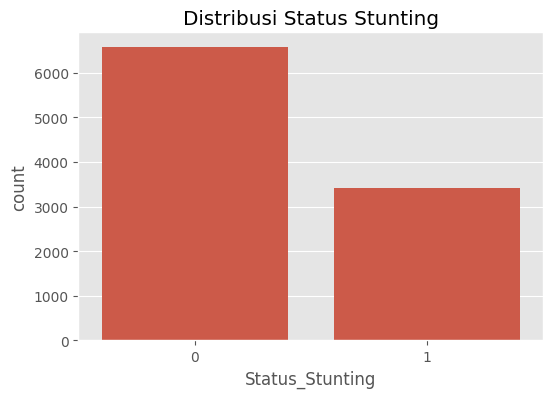

In [9]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Status_Stunting"
)

plt.title("Distribusi Status Stunting")
plt.show()

**Persentase Target**

In [10]:
df["Status_Stunting"].value_counts(normalize=True)*100

,proportion
Status_Stunting,
0,65.73
1,34.27


**Distribusi Umur**

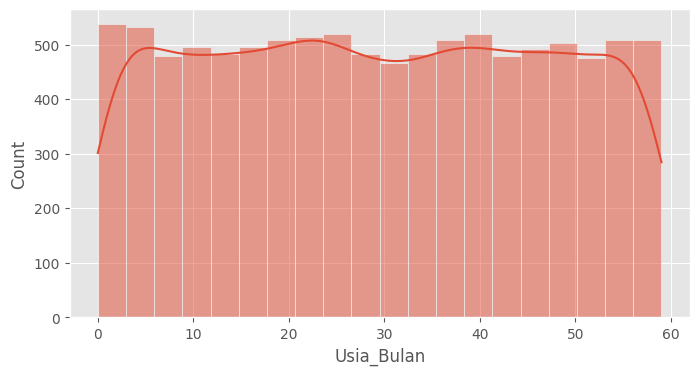

In [11]:
plt.figure(figsize=(8,4))

sns.histplot(
    df["Usia_Bulan"],
    bins=20,
    kde=True
)

plt.show()

**Distribusi Berat Badan**

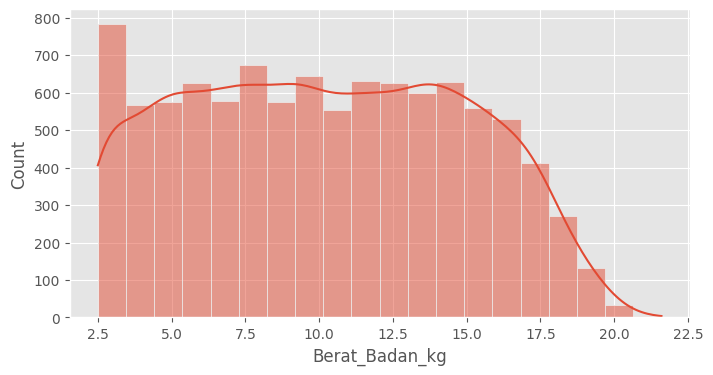

In [12]:
plt.figure(figsize=(8,4))

sns.histplot(
    df["Berat_Badan_kg"],
    bins=20,
    kde=True
)

plt.show()

**Distribusi Tinggi Badan**

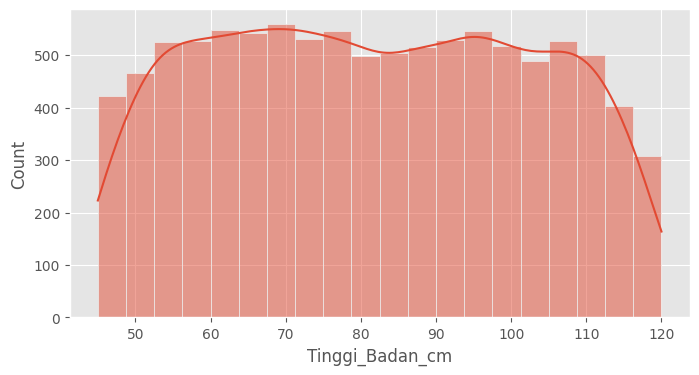

In [13]:
plt.figure(figsize=(8,4))

sns.histplot(
    df["Tinggi_Badan_cm"],
    bins=20,
    kde=True
)

plt.show()

**Distribusi Provinsi**

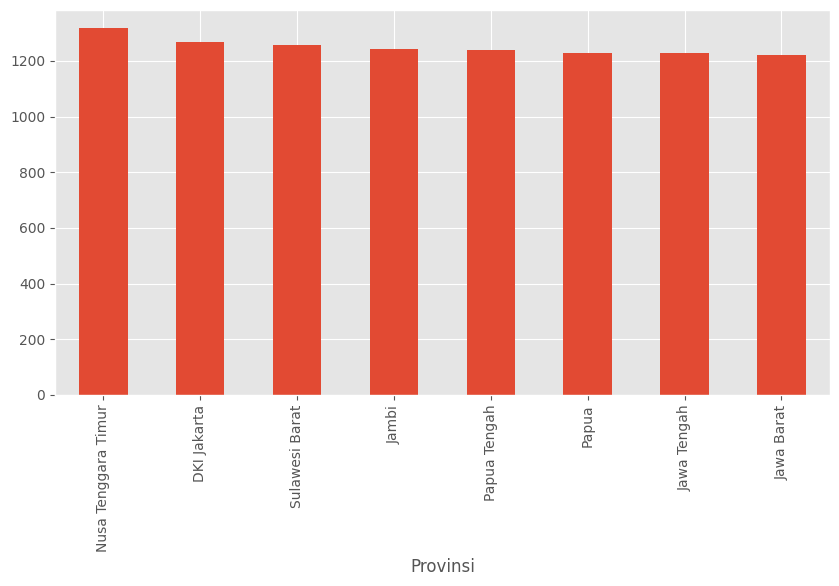

In [14]:
plt.figure(figsize=(10,5))

df["Provinsi"].value_counts().plot.bar()

plt.show()

**Distribusi Kabupaten**

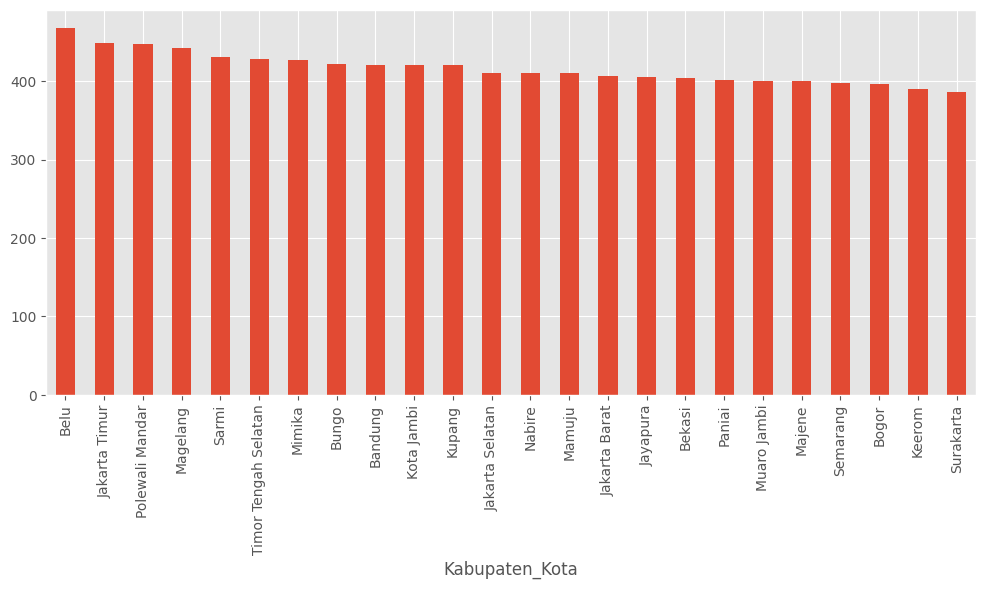

In [15]:
plt.figure(figsize=(12,5))

df["Kabupaten_Kota"].value_counts().plot.bar()

plt.show()

**Distribusi Jenis Kelamin**

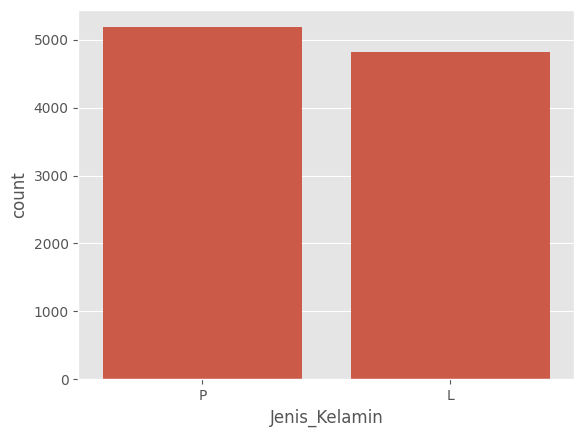

In [16]:
sns.countplot(
    data=df,
    x="Jenis_Kelamin"
)

plt.show()

**Korelasi Numerik**

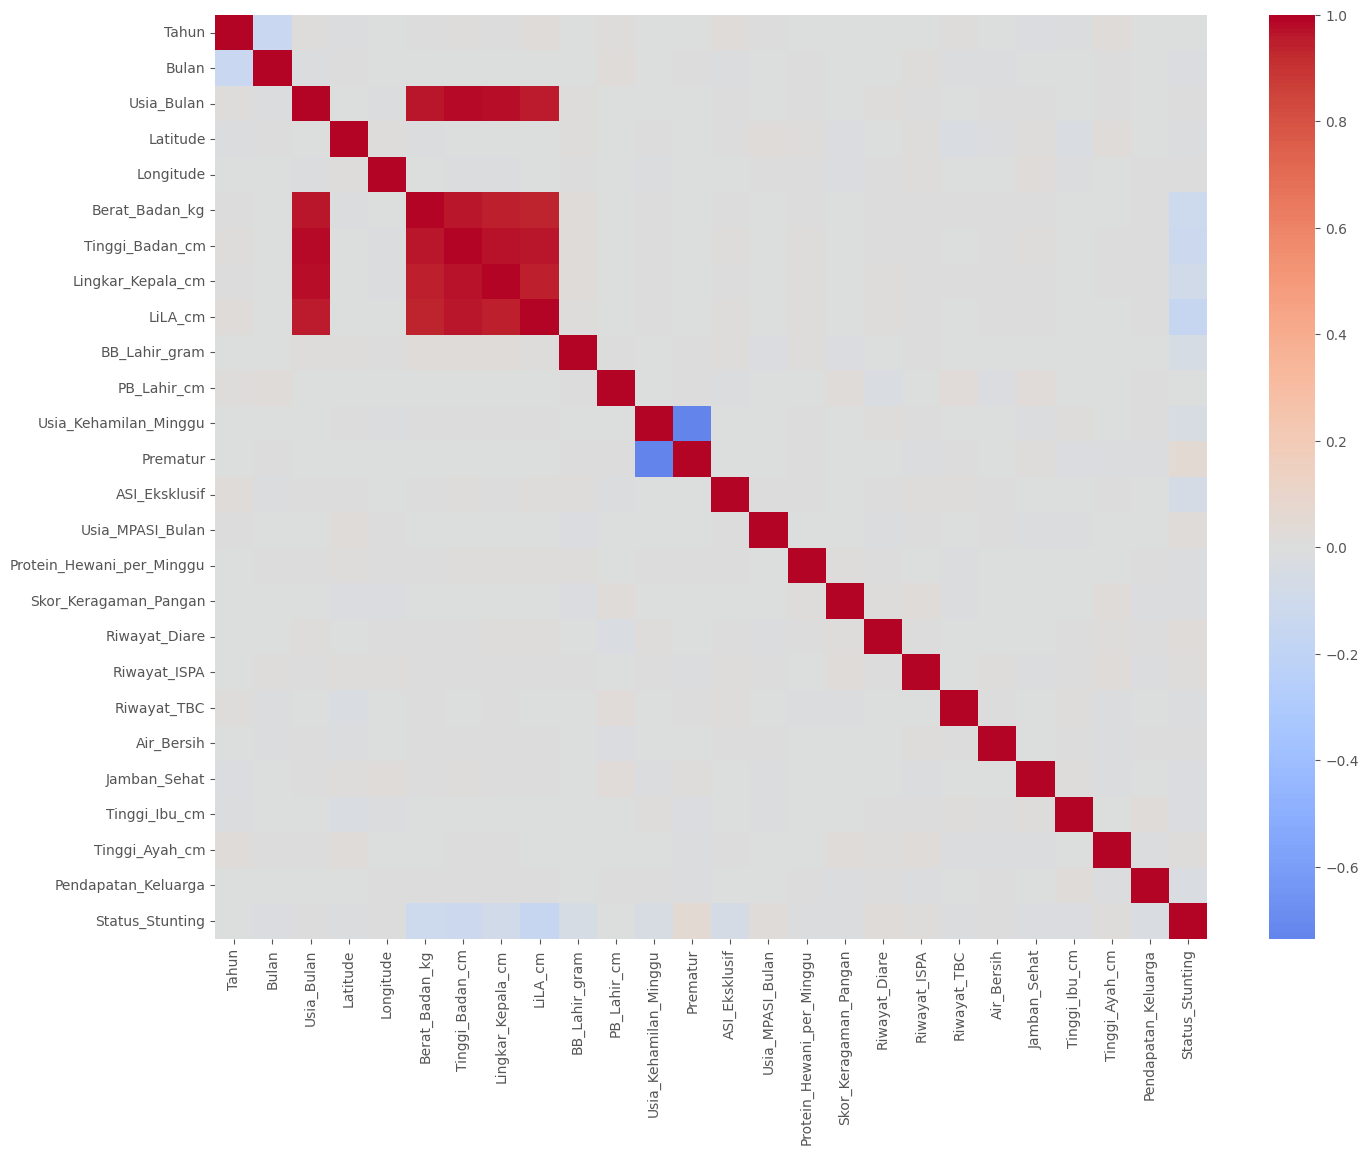

In [17]:
numeric = df.select_dtypes(include=np.number)

corr = numeric.corr()

plt.figure(figsize=(16,12))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.show()

**Korelasi Terhadap Target**

In [18]:
corr_target = corr["Status_Stunting"]\
                    .sort_values(ascending=False)

corr_target

,Status_Stunting
Status_Stunting,1.000000
Prematur,0.046935
Riwayat_Diare,0.022919
Usia_MPASI_Bulan,0.020218
Riwayat_ISPA,0.013815
Tinggi_Ayah_cm,0.010824
Longitude,0.008250
Usia_Bulan,0.006367
Air_Bersih,0.003599
PB_Lahir_cm,-0.004301


**Boxplot Outlier**

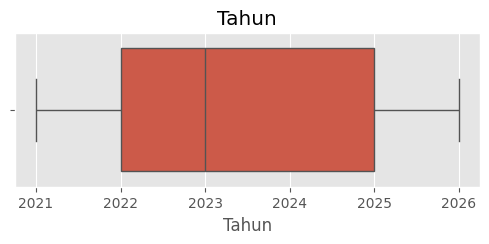

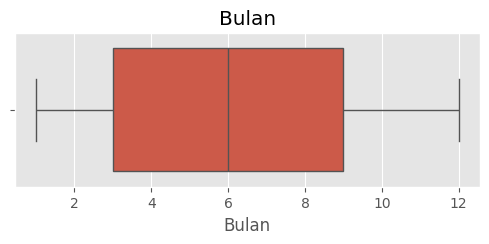

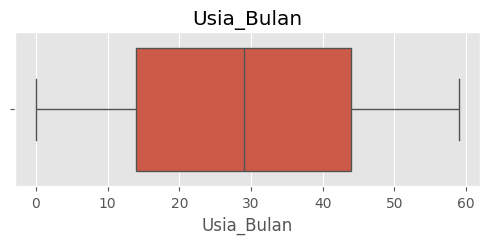

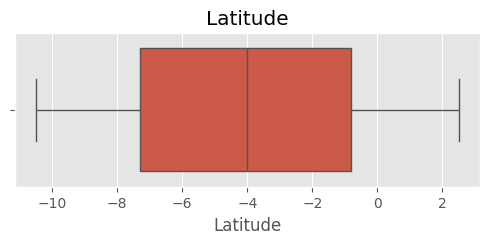

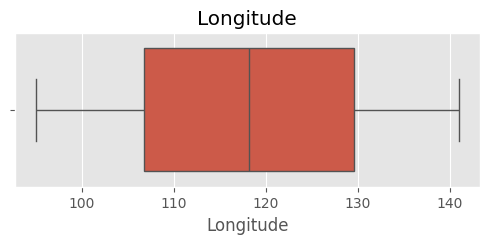

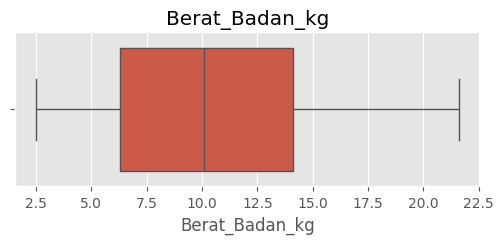

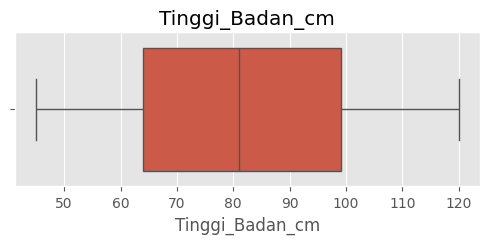

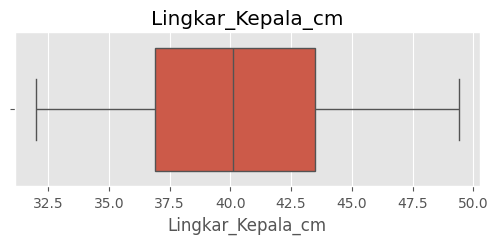

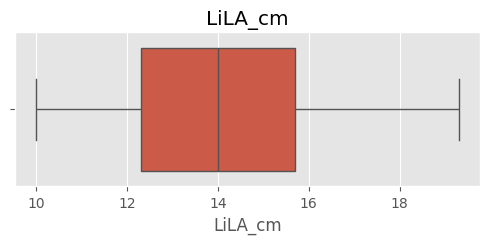

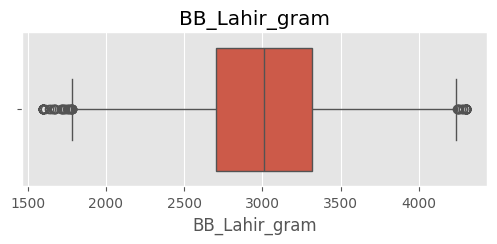

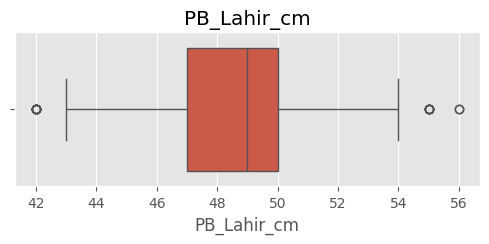

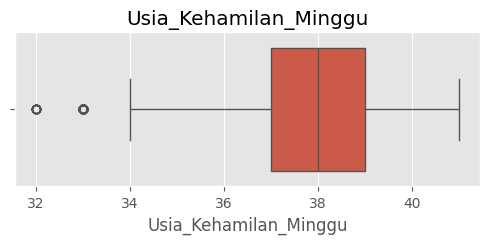

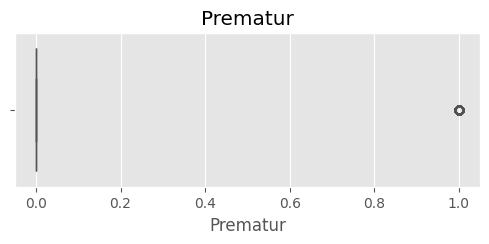

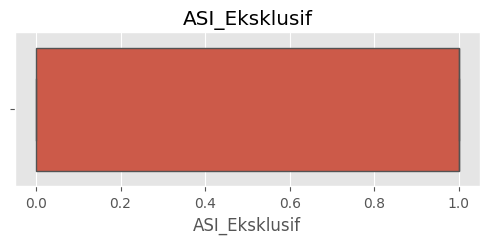

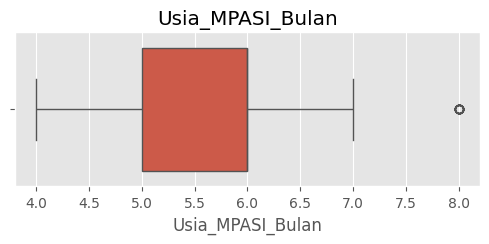

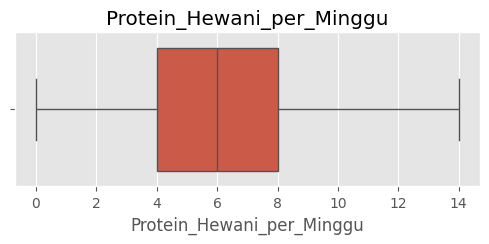

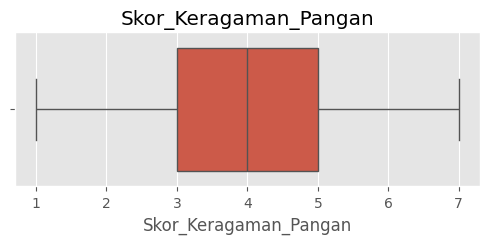

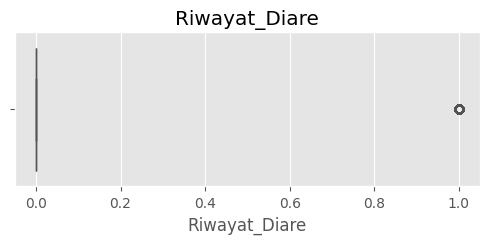

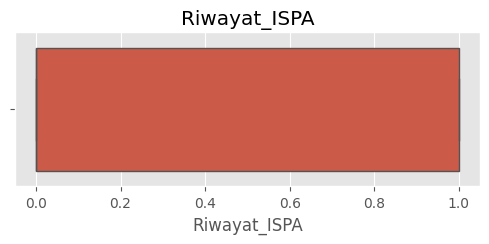

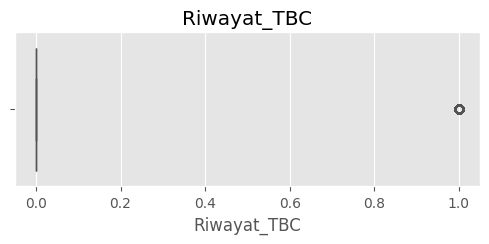

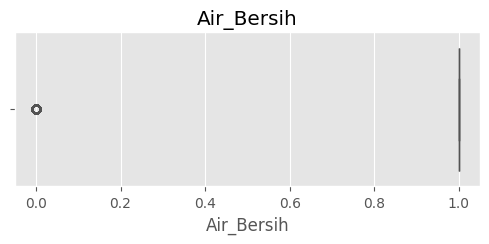

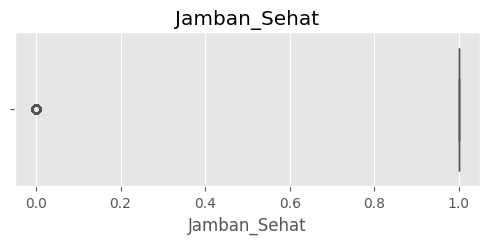

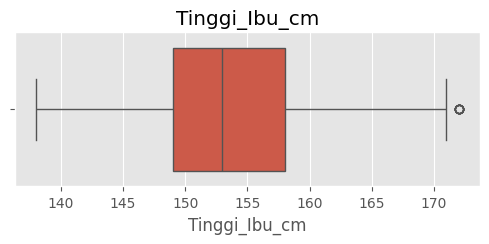

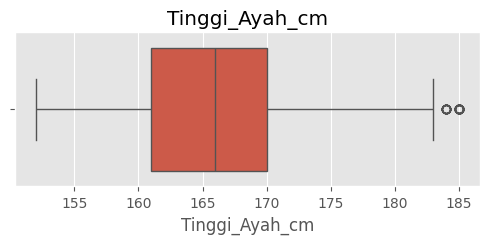

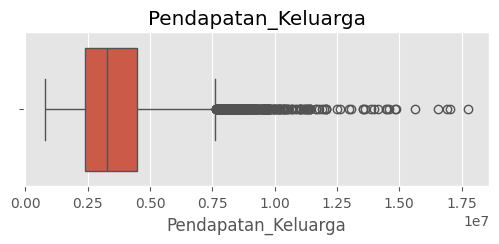

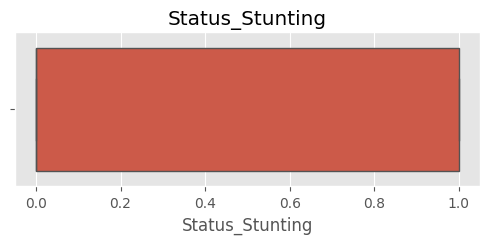

In [19]:
numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:

    plt.figure(figsize=(6,2))

    sns.boxplot(
        x=df[col]
    )

    plt.title(col)

    plt.show()